<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


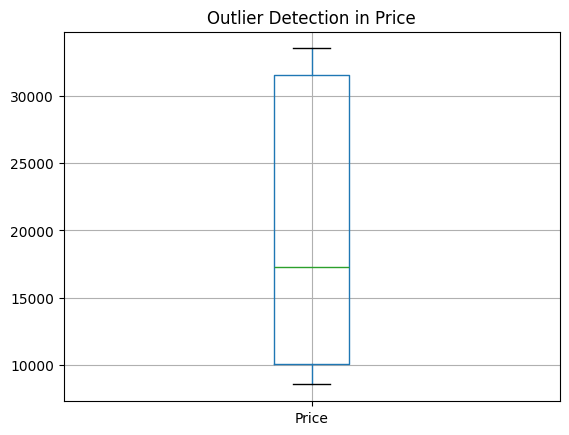

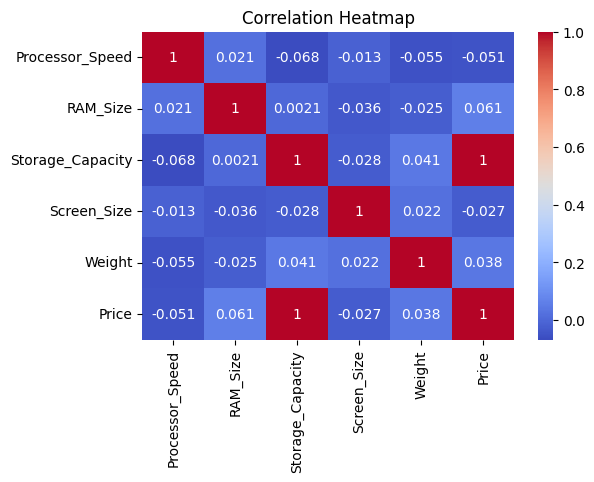

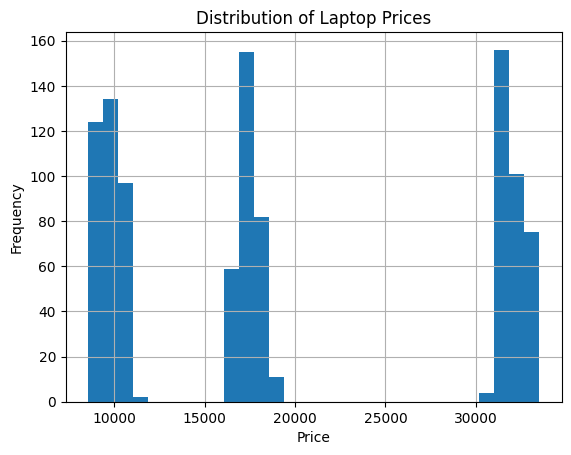

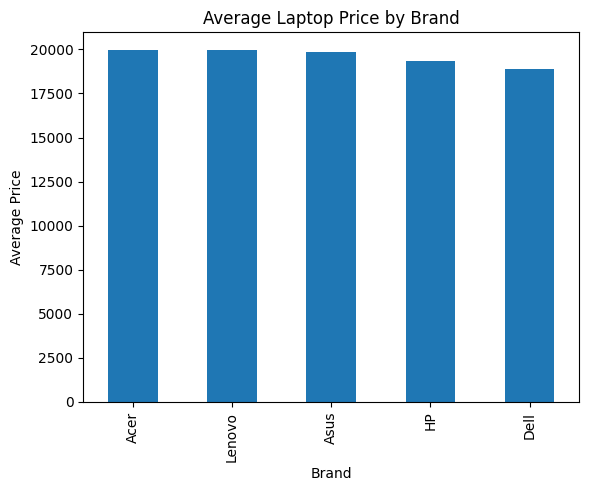

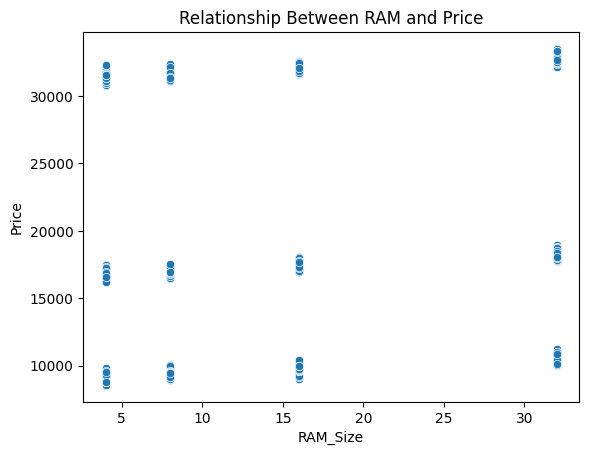

Linear Regression Performance:
R2 Score: 0.999650437909869
MAE: 144.3327461386291
RMSE: 178.15451757194754


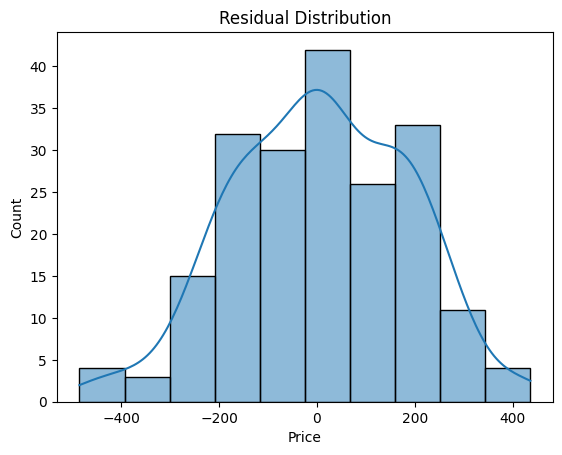

Trained model saved successfully.


In [5]:
# =========================================================
# 1. Import Required Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

# =========================================================
# 2. Load the Dataset
# =========================================================
data = pd.read_csv("https://raw.githubusercontent.com/jyothyprakash90/Datasets/refs/heads/main/Laptop_price.csv")

# Preview the dataset
data.head()

# =========================================================
# 3. Data Quality Checks
# =========================================================
data.info()
data.shape
data.isnull().sum()
data.duplicated().sum()
data.describe()

# =========================================================
# 4. Outlier Detection
# =========================================================
plt.figure()
data.boxplot(column="Price")
plt.title("Outlier Detection in Price")
plt.show()

# =========================================================
# 5. Correlation Analysis
# =========================================================
numeric_data = data.select_dtypes(include=["number"])
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================================================
# 6. Exploratory Data Analysis (EDA)
# =========================================================

# 6.1 Price Distribution
plt.figure()
data["Price"].hist(bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# 6.2 Brand vs Price
plt.figure()
data.groupby("Brand")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Laptop Price by Brand")
plt.ylabel("Average Price")
plt.show()

# 6.3 RAM vs Price
plt.figure()
sns.scatterplot(x="RAM_Size", y="Price", data=data)
plt.title("Relationship Between RAM and Price")
plt.show()

# =========================================================
# 7. Feature Selection
# =========================================================
X = data[["Processor_Speed", "RAM_Size", "Storage_Capacity"]]
y = data["Price"]

# =========================================================
# 8. Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 9. Model Building (Linear Regression)
# =========================================================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================================================
# 10. Prediction
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# 11. Model Evaluation
# =========================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression Performance:")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# =========================================================
# 12. Residual Analysis
# =========================================================
residuals = y_test - y_pred
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# =========================================================
# 13. Model Saving
# =========================================================
joblib.dump(model, "laptop_price_linear_model.pkl")
print("Trained model saved successfully.")
